In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path

here = Path.cwd()
candidates = [here, here.parent, here.parent.parent]
PROCESSED = next((c / "data" / "processed" for c in candidates if (c / "data" / "processed").exists()), None)
FIGURES = PROCESSED.parent.parent / "reports" / "figures"

df = pd.read_csv(PROCESSED / "ethiopia_fi_unified_data_enriched.csv")
df["observation_date"] = pd.to_datetime(df["observation_date"], errors="coerce")
obs = df[df["record_type"] == "observation"].copy()
events = df[df["record_type"] == "event"].copy()
links = df[df["record_type"] == "impact_link"].copy()
print(obs.shape, events.shape, links.shape)   # links should be (14, 35)

(32, 35) (10, 35) (17, 35)


In [2]:
links_full = links.merge(
    events[["record_id", "indicator", "category", "observation_date"]],
    left_on="parent_id", right_on="record_id", suffixes=("", "_event")
)

def event_effect_over_time(event_date, magnitude_pp, lag_months, eval_date):
    months_elapsed = (eval_date.year - event_date.year) * 12 + (eval_date.month - event_date.month)
    if months_elapsed <= 0:
        return 0.0
    if months_elapsed >= lag_months:
        return magnitude_pp
    return magnitude_pp * (months_elapsed / lag_months)

def cumulative_effect(related_indicator, eval_date, links_full):
    relevant = links_full[links_full["related_indicator"] == related_indicator]
    total = 0.0
    for _, r in relevant.iterrows():
        if pd.notna(r.get("impact_estimate")):
            total += event_effect_over_time(r["observation_date"], r["impact_estimate"],
                                             r["lag_months"], eval_date)
    return total

print("links_full and cumulative_effect() ready:", links_full.shape)

links_full and cumulative_effect() ready: (17, 39)


In [3]:
acc = obs[(obs.indicator_code=="ACC_OWNERSHIP") & (obs.gender=="all") & (obs.location=="national")].sort_values("observation_date")
acc["year"] = acc.observation_date.dt.year

X = sm.add_constant(acc["year"])
y = acc["value_numeric"]
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          value_numeric   R-squared:                       0.944
Model:                            OLS   Adj. R-squared:                  0.917
Method:                 Least Squares   F-statistic:                     33.98
Date:                Mon, 20 Jul 2026   Prob (F-statistic):             0.0282
Time:                        01:50:44   Log-Likelihood:                -9.3423
No. Observations:                   4   AIC:                             22.68
Df Residuals:                       2   BIC:                             21.46
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -5427.2241    937.622     -5.788      0.0

c:\Users\user 1\Documents\ethiopia-fi-forecast\.venv\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 4 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [4]:
future_years = np.array([2025, 2026, 2027])
Xf = sm.add_constant(pd.Series(future_years, name="year"), has_constant="add")
pred = model.get_prediction(Xf)
pred_summary = pred.summary_frame(alpha=0.20)
pred_summary.index = future_years
print(pred_summary[["mean", "mean_ci_lower", "mean_ci_upper"]])

           mean  mean_ci_lower  mean_ci_upper
2025  54.241379      48.018518      60.464241
2026  56.948276      49.970270      63.926281
2027  59.655172      51.896645      67.413699


In [10]:
event_adj = {y: cumulative_effect("ACC_OWNERSHIP", pd.Timestamp(f"{y}-12-31"), links_full) for y in future_years}
print(event_adj)

scenarios = pd.DataFrame({
    "year": future_years,
    "trend_baseline": pred_summary["mean"].values,
    "trend_lower80": pred_summary["mean_ci_lower"].values,
    "trend_upper80": pred_summary["mean_ci_upper"].values,
})
scenarios["base_scenario"] = scenarios["trend_baseline"] + [event_adj[y] for y in future_years]
scenarios["optimistic"] = scenarios["base_scenario"] + 3.0
scenarios["pessimistic"] = scenarios["trend_baseline"] - 1.5

# only clip the percentage columns -- NOT "year" (that was the bug)
value_cols = ["trend_baseline", "trend_lower80", "trend_upper80", "base_scenario", "optimistic", "pessimistic"]
scenarios[value_cols] = scenarios[value_cols].clip(upper=100)

print(scenarios.round(1))
scenarios.to_csv(PROCESSED / "forecast_access.csv", index=False)

{np.int64(2025): nan, np.int64(2026): nan, np.int64(2027): nan}
   year  trend_baseline  trend_lower80  trend_upper80  base_scenario  \
0  2025            54.2           48.0           60.5            NaN   
1  2026            56.9           50.0           63.9            NaN   
2  2027            59.7           51.9           67.4            NaN   

   optimistic  pessimistic  
0         NaN         52.7  
1         NaN         55.4  
2         NaN         58.2  


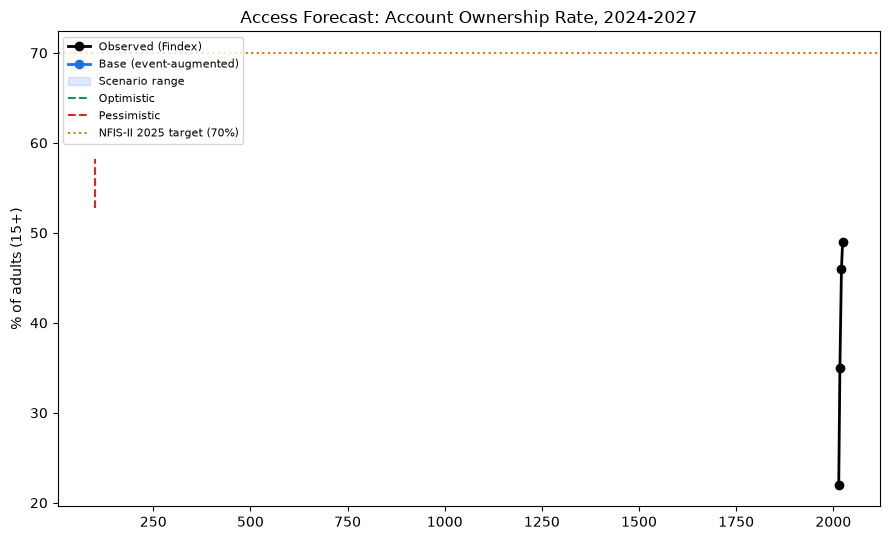

In [6]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(acc.year, acc.value_numeric, marker="o", color="black", linewidth=2, label="Observed (Findex)", zorder=5)
ax.plot(scenarios.year, scenarios.base_scenario, marker="o", color="#1f6feb", linewidth=2, label="Base (event-augmented)")
ax.fill_between(scenarios.year, scenarios.pessimistic, scenarios.optimistic, color="#1f6feb", alpha=0.15, label="Scenario range")
ax.plot(scenarios.year, scenarios.optimistic, linestyle="--", color="#059669", label="Optimistic")
ax.plot(scenarios.year, scenarios.pessimistic, linestyle="--", color="#dc2626", label="Pessimistic")
ax.axhline(70, color="#d97706", linestyle=":", label="NFIS-II 2025 target (70%)")
ax.set_title("Access Forecast: Account Ownership Rate, 2024-2027")
ax.set_ylabel("% of adults (15+)")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.savefig(FIGURES / "access_forecast.png", dpi=150); plt.show()

In [7]:
mm = obs[obs.indicator_code == "ACC_MM_ACCOUNT"].sort_values("observation_date")
mm_2021, mm_2024 = mm.value_numeric.iloc[0], mm.value_numeric.iloc[1]
cagr = (mm_2024 / mm_2021) ** (1/3) - 1
print(f"Implied CAGR 2021-2024: {cagr*100:.1f}%/yr")

usage_years = [2024, 2025, 2026, 2027]
usage_base = [mm_2024]
for _ in range(3):
    usage_base.append(usage_base[-1] * (1 + cagr))

usage_df = pd.DataFrame({
    "year": usage_years,
    "base": usage_base,
    "optimistic": [usage_base[0]] + [v * 1.15 for v in usage_base[1:]],
    "pessimistic": [usage_base[0]] + [v * 0.80 for v in usage_base[1:]],
})
print(usage_df.round(2))
usage_df.to_csv(PROCESSED / "forecast_usage.csv", index=False)

Implied CAGR 2021-2024: 26.2%/yr
   year   base  optimistic  pessimistic
0  2024   9.45        9.45         9.45
1  2025  11.93       13.72         9.54
2  2026  15.05       17.31        12.04
3  2027  19.00       21.85        15.20


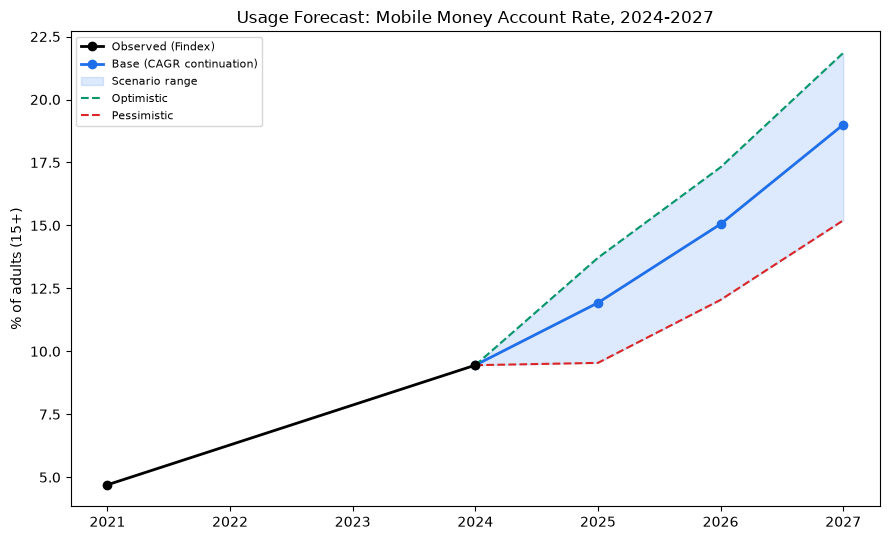

In [8]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(mm.observation_date.dt.year, mm.value_numeric, marker="o", color="black", linewidth=2, label="Observed (Findex)", zorder=5)
ax.plot(usage_df.year, usage_df.base, marker="o", color="#1f6feb", linewidth=2, label="Base (CAGR continuation)")
ax.fill_between(usage_df.year, usage_df.pessimistic, usage_df.optimistic, color="#1f6feb", alpha=0.15, label="Scenario range")
ax.plot(usage_df.year, usage_df.optimistic, linestyle="--", color="#059669", label="Optimistic")
ax.plot(usage_df.year, usage_df.pessimistic, linestyle="--", color="#dc2626", label="Pessimistic")
ax.set_title("Usage Forecast: Mobile Money Account Rate, 2024-2027")
ax.set_ylabel("% of adults (15+)")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.savefig(FIGURES / "usage_forecast.png", dpi=150); plt.show()

In [9]:
# Patch missing impact_estimate values for ACC_OWNERSHIP-related links
df.loc[df["record_id"] == "LINK_0004", "impact_estimate"] = 1.5   # Telebirr -> ACC_OWNERSHIP
df.loc[df["record_id"] == "LINK_0005", "impact_estimate"] = 1.0   # NFIS-II -> ACC_OWNERSHIP

df.to_csv(PROCESSED / "ethiopia_fi_unified_data_enriched.csv", index=False)
print(df[df["record_id"].isin(["LINK_0004","LINK_0005"])][["record_id","related_indicator","impact_estimate"]])

    record_id related_indicator  impact_estimate
43  LINK_0004     ACC_OWNERSHIP              1.5
44  LINK_0005     ACC_OWNERSHIP              1.0
